<a href="https://colab.research.google.com/github/Krispavnn555/NASSCOM_FDP/blob/main/DAY2_U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U6 — Probability & Statistics (Part 1): Lab

**Descriptive Statistics** — central tendency · spread · shape · correlation · summarizing data

_Day 2 · Phase B — Mathematical Foundations · Built from Module 1.4 + 2.2_

#objectives

By the end of this lab you will be able to:

Tell categorical and numerical variables apart and pick the right statistic

Compute measures of central tendency: mean, median and mode

Compute measures of spread: range, variance, standard deviation and IQR

Describe the shape of a distribution with the five-number summary and a box plot

Measure how variables relate with correlation, and summarise a whole dataset at once

#how to use this lab

Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**. Run the demos before attempting the exercises.

In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#1. Types of data & variables

In [ ]:
# -----------------------------------------------------------
# 🔹 1A. NUMERICAL vs CATEGORICAL COLUMNS
# -----------------------------------------------------------

# .dtypes tells you each column's type: float/int = numerical, object/category = categorical
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. WHICH STATISTIC FITS WHICH TYPE
# -----------------------------------------------------------

# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


#### 🧪 LAB EXERCISE 1 — Classify the columns

1. Print the list of **numerical** columns and the list of **categorical** columns.
2. For a numerical column (e.g. `tip`), print its **mean**.
3. For a categorical column (e.g. `sex`), print its **value counts**.

In [4]:
# 1. Numerical vs categorical columns
print('Numerical columns:', numerical)
print('Categorical columns:', categorical)

# 2. Mean of a numerical column (tip)
print('Mean of tip:', round(df['tip'].mean(), 2))

# 3. Value counts of a categorical column (sex)
print('Sex value counts:')
print(df['sex'].value_counts())

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']
Mean of tip: 3.0
Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


#2. Measures of central tendency

In [5]:
# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


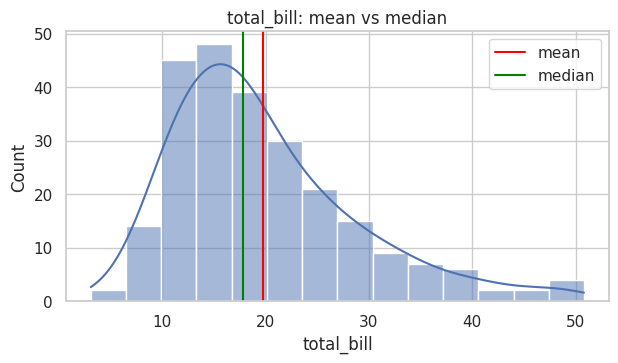

In [6]:
# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

#### 🧪 LAB EXERCISE 2 — Central tendency

For the **`tip`** column:
1. Print its mean, median and mode.
2. Is it right-skewed? Check whether `mean > median`.
3. Plot a histogram of `tip` with vertical lines at the mean and median.

Mean   : 3.0
Median : 2.9
Mode   : 2.0
mean > median ? True -> right-skewed


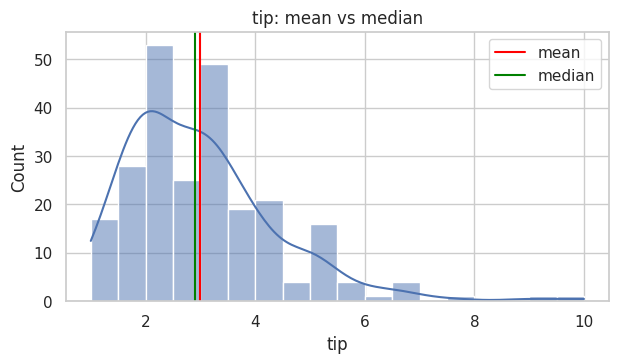

In [8]:
tip = df['tip']

# 1. mean, median, mode
print('Mean   :', round(tip.mean(), 2))
print('Median :', round(tip.median(), 2))
print('Mode   :', round(tip.mode()[0], 2))

# 2. mean > median ?
print('mean > median ?', tip.mean() > tip.median(), '-> right-skewed')

# 3. histogram with mean & median lines (reuse the pattern from 2B)
plt.figure(figsize=(7, 3.5))
sns.histplot(tip, kde=True)
plt.axvline(tip.mean(),   color='red',   label='mean')
plt.axvline(tip.median(), color='green', label='median')
plt.legend(); plt.title('tip: mean vs median'); plt.show()

#3. Measures of spread (dispersion)

In [9]:
# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)

Range : 47.74
Var   : 79.25
Std   : 8.9


In [10]:
# -----------------------------------------------------------
# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
# -----------------------------------------------------------

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


#### 🧪 LAB EXERCISE 3 — Spread

For the **`tip`** column:
1. Print the range, variance and standard deviation.
2. Compute Q1, Q3 and the **IQR**.
3. In a comment, say which measure of spread is most robust to outliers and why.

In [11]:
tip = df['tip']

# 1. range, variance, std
print('Range :', round(tip.max() - tip.min(), 2))
print('Var   :', round(tip.var(), 2))
print('Std   :', round(tip.std(), 2))

# 2. Q1, Q3, IQR
q1, q3 = tip.quantile(0.25), tip.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2))

# 3. Most robust measure of spread = ?   (write your answer here)
# The Interquartile Range (IQR) is the most robust measure of spread to outliers
# because it focuses on the middle 50% of the data, ignoring extreme values.

Range : 9.0
Var   : 1.91
Std   : 1.38
Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56


#4. Shape: five-number summary & box plot

In [12]:
# -----------------------------------------------------------
# 🔹 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
# -----------------------------------------------------------

col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


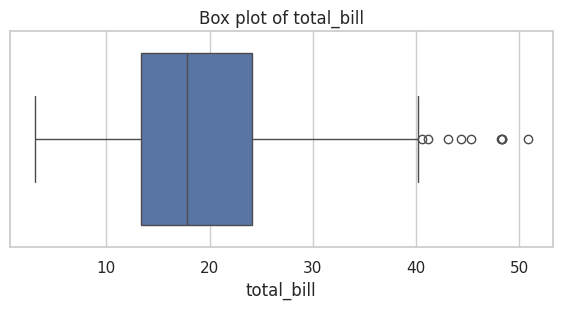

In [13]:
# -----------------------------------------------------------
# 🔹 4B. BOX PLOT (a picture of the five-number summary)
# -----------------------------------------------------------

# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

#### 🧪 LAB EXERCISE 4 — Five-number summary & box plot

For the **`tip`** column:
1. Print its five-number summary (min, 25%, 50%, 75%, max).
2. Print its skewness and say (in a comment) which way it leans.
3. Draw a box plot of `tip`.

Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


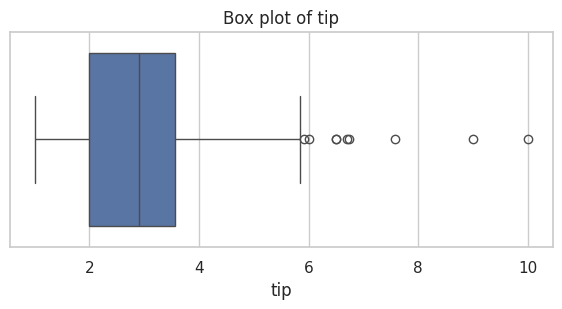

In [14]:
tip = df['tip']

# 1. five-number summary
five_num_summary = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print('Five-number summary:')
print(five_num_summary)

# 2. skewness (+ comment on the direction of the lean)
skewness = tip.skew()
print('\nSkewness:', round(skewness, 3))
# Skewness > 0 indicates a right-skewed distribution.
# Skewness < 0 indicates a left-skewed distribution.
# Skewness ~ 0 indicates a symmetric distribution.

# 3. box plot of tip
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=tip)
plt.title('Box plot of tip'); plt.show()

#5. Correlation & summarizing a dataset

In [15]:
# -----------------------------------------------------------
# 🔹 5A. CORRELATION between numerical columns
# -----------------------------------------------------------

# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


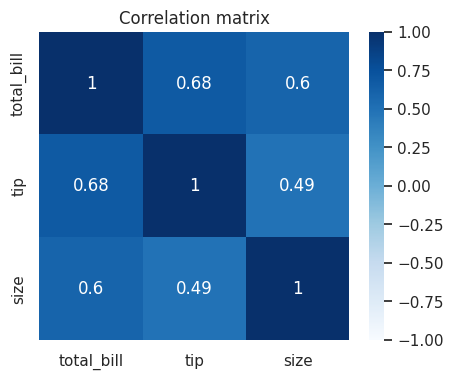

In [16]:
# -----------------------------------------------------------
# 🔹 5B. VISUALISE THE CORRELATION MATRIX
# -----------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [17]:
# -----------------------------------------------------------
# 🔹 5C. ONE-SHOT SUMMARY with .describe()
# -----------------------------------------------------------

# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


#### 🧪 LAB EXERCISE 5 — Correlation & full summary

1. Build the correlation matrix and print it (rounded to 2 decimals).
2. Draw a correlation **heatmap**.
3. Run `df.describe()` and, in a comment, write **3 insights** about the dataset (e.g. which column is most spread out, which pair is most correlated, any skew you notice).

Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


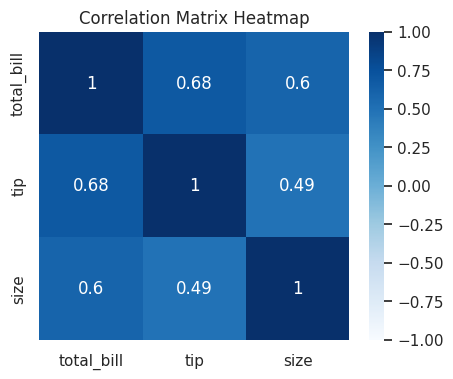


Dataset Summary (df.describe()):


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [18]:
# 1. correlation matrix (rounded)
corr_matrix = df.corr(numeric_only=True).round(2)
print('Correlation Matrix:')
print(corr_matrix)

# 2. heatmap of the correlation matrix
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap');
plt.show()

# 3. df.describe() + 3 insights as comments
print('\nDataset Summary (df.describe()):')
display(df.describe())
# Insight 1: The 'total_bill' column has the largest standard deviation (8.90), indicating the most spread-out data among numerical columns.
# Insight 2: All numerical columns ('total_bill', 'tip', 'size') show a positive skew, as their mean values are greater than their medians, suggesting a tail extending towards higher values.
# Insight 3: 'total_bill' and 'tip' have a strong positive correlation (0.68), meaning that as total bill increases, the tip amount tends to increase as well.

#📘 Summary — Descriptive Statistics toolkit

| Concept | What it tells you | Key calls |
| ------- | ----------------- | --------- |
| **Data type** | which statistics are valid | `.dtypes`, `select_dtypes`, `value_counts` |
| **Central tendency** | where the data sits | `.mean()`, `.median()`, `.mode()` |
| **Spread** | how dispersed it is | `.var()`, `.std()`, range, `.quantile()` → IQR |
| **Shape** | how it leans / its quartiles | `.skew()`, five-number summary, `sns.boxplot` |
| **Correlation** | how variables relate | `.corr()`, `sns.heatmap` |
| **One-shot summary** | everything at once | `.describe()` |

**Homework (self-paced):** mean/median/mode on a CSV · variance, std & IQR for a column · five-number summary + box plot · a correlation matrix · 3 insights from `.describe()`.

**Next — Part 2 (Day 3):** probability theory & axioms · conditional probability · Bayes' theorem · distributions (Gaussian, Poisson, Bernoulli) · entropy, KL divergence & mutual information.